In [4]:
import numpy as np

# Update this path to your .npz file
npz_path = "/mnt/d/lari/eval_scrream/scene01/scene01_full_00/ldi/000035_ldi.npz"

with np.load(npz_path, allow_pickle=True) as data:
    print("Files in archive:", data.files)
    for key in data.files:
        arr = data[key]
        print(f"\nKey: {key}")
        print(f"Type: {type(arr)}, Shape: {getattr(arr, 'shape', None)}, Dtype: {getattr(arr, 'dtype', None)}")
        print("Content:")
        print(arr)
        print(arr[0,0])

Files in archive: ['ldi']

Key: ldi
Type: <class 'numpy.ndarray'>, Shape: (874, 1132, 10), Dtype: float16
Content:
[[[ 1.786 -1.    -1.    ... -1.    -1.    -1.   ]
  [ 1.788 -1.    -1.    ... -1.    -1.    -1.   ]
  [ 1.79   1.797  1.801 ... -1.    -1.    -1.   ]
  ...
  [ 1.038 -1.    -1.    ... -1.    -1.    -1.   ]
  [ 1.037 -1.    -1.    ... -1.    -1.    -1.   ]
  [ 1.036 -1.    -1.    ... -1.    -1.    -1.   ]]

 [[ 1.787 -1.    -1.    ... -1.    -1.    -1.   ]
  [ 1.788 -1.    -1.    ... -1.    -1.    -1.   ]
  [ 1.79   1.799  1.801 ... -1.    -1.    -1.   ]
  ...
  [ 1.038 -1.    -1.    ... -1.    -1.    -1.   ]
  [ 1.037 -1.    -1.    ... -1.    -1.    -1.   ]
  [ 1.037 -1.    -1.    ... -1.    -1.    -1.   ]]

 [[ 1.787 -1.    -1.    ... -1.    -1.    -1.   ]
  [ 1.789 -1.    -1.    ... -1.    -1.    -1.   ]
  [ 1.79   1.8    1.801 ... -1.    -1.    -1.   ]
  ...
  [ 1.038 -1.    -1.    ... -1.    -1.    -1.   ]
  [ 1.037 -1.    -1.    ... -1.    -1.    -1.   ]
  [ 1.037 -1.

In [9]:
import json
from pathlib import Path

# Config
DATA_ROOT = "/mnt/d/scannet/data"

# Find all scene folders containing a 'panocam' directory
# AND a 'scans' directory with a 'scanner_poses.json' file
valid_scenes = []
for p in Path(DATA_ROOT).glob("*/panocam"):
    if p.is_dir():
        scene_dir = p.parent
        scans_dir = scene_dir / "scans"
        # Check for scans folder and scanner_poses.json
        if scans_dir.is_dir() and (scans_dir / "scanner_poses.json").exists():
            valid_scenes.append(str(scene_dir))

# Return as JSON
print(json.dumps({"scenes": sorted(valid_scenes)}, indent=4))

with open("scenes_with_pcd.json", "w") as f:
    json.dump({"scenes": sorted(valid_scenes)}, f, indent=4)

{
    "scenes": [
        "/mnt/d/scannet/data/07f5b601ee",
        "/mnt/d/scannet/data/07ff1c45bb",
        "/mnt/d/scannet/data/08bbbdcc3d",
        "/mnt/d/scannet/data/09bced689e",
        "/mnt/d/scannet/data/0b031f3119",
        "/mnt/d/scannet/data/0c5385e84b",
        "/mnt/d/scannet/data/0d41f3a279",
        "/mnt/d/scannet/data/116456116b",
        "/mnt/d/scannet/data/1ae9e5d2a6",
        "/mnt/d/scannet/data/1b9692f0c7",
        "/mnt/d/scannet/data/210f741378",
        "/mnt/d/scannet/data/25aa952aa3",
        "/mnt/d/scannet/data/260db9cf5a",
        "/mnt/d/scannet/data/281bc17764",
        "/mnt/d/scannet/data/28a9ee4557",
        "/mnt/d/scannet/data/2b1dc6d6a5",
        "/mnt/d/scannet/data/2e74812d00",
        "/mnt/d/scannet/data/30f4a2b44d",
        "/mnt/d/scannet/data/37ea1c52f0",
        "/mnt/d/scannet/data/3928249b53",
        "/mnt/d/scannet/data/39f36da05b",
        "/mnt/d/scannet/data/4ba22fa7e4",
        "/mnt/d/scannet/data/56a0ec536c",
        "/mnt/d/

In [3]:
arr = [1,2,3,4]

list = [arr[:]]
print(list)

[[1, 2, 3, 4]]


,CD_8192_full,f_score_0.1_full,f_score_0.05_full,f_score_0.02_full
07f5b601ee,0.036401,0.960080,0.778108,0.350329
07ff1c45bb,0.029017,0.982541,0.862947,0.434527
08bbbdcc3d,0.272527,0.321669,0.184170,0.059437
09bced689e,0.079045,0.667475,0.401239,0.230552
0b031f3119,0.164868,0.423030,0.273793,0.136619
0c5385e84b,0.017853,0.995441,0.970699,0.714581
0d41f3a279,0.020187,0.992605,0.950741,0.663036
116456116b,0.057065,0.828516,0.547176,0.271658
1ae9e5d2a6,0.057394,0.850905,0.511535,0.188103
1b9692f0c7,0.020689,0.992179,0.944311,0.643586


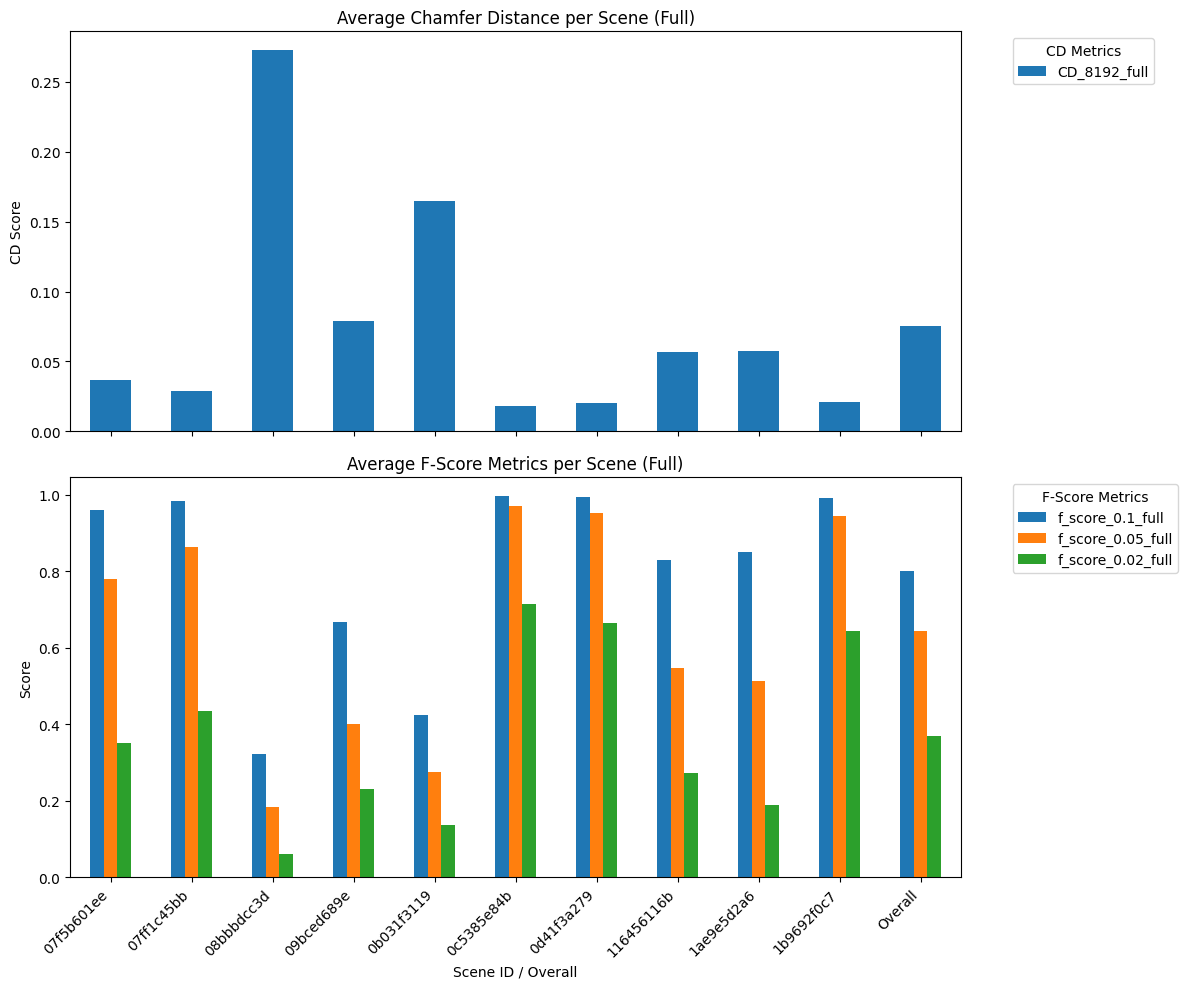

In [6]:
import json
import pandas as pd
import matplotlib.pyplot as plt

with open("./nova3r/evaluation_results_ae.json", "r") as f:
    results = json.load(f)

# per scene avg
per_scene_avg = {}
for scene, scene_results in results.items():
    score = {}
    for metric in scene_results[0].keys():
        if "full" not in metric:
            continue
        metric_values = [res[metric][0] for res in scene_results if metric in res]
        if metric_values:
            score[metric] = sum(metric_values) / len(metric_values)
    per_scene_avg[scene.split("/")[-1]] = score

# Create a DataFrame for better tabular visualization
df = pd.DataFrame(per_scene_avg).T

# Add an overall average row
df.loc["Overall"] = df.mean()

display(df)

# Separate metrics into Chamfer Distance and others (F-scores)
cd_cols = [c for c in df.columns if "CD" in c]
other_cols = [c for c in df.columns if "CD" not in c]

# Plot bar charts in two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

if cd_cols:
    df[cd_cols].plot(kind="bar", ax=ax1, rot=0)
    ax1.set_title("Average Chamfer Distance per Scene (Full)")
    ax1.set_ylabel("CD Score")
    ax1.set_xlabel("")
    ax1.tick_params(axis='x', labelbottom=False)  # Hide x-labels for the top plot
    ax1.legend(title="CD Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')

if other_cols:
    df[other_cols].plot(kind="bar", ax=ax2, rot=45)
    ax2.set_title("Average F-Score Metrics per Scene (Full)")
    ax2.set_ylabel("Score")
    ax2.set_xlabel("Scene ID / Overall")
    # Align labels to the right for better readability when rotated
    plt.setp(ax2.xaxis.get_majorticklabels(), ha='right')
    ax2.legend(title="F-Score Metrics", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

python demo_nova3r.py   --images demo/examples/scrream_scene09_200.png demo/examples/scrream_scene09_275.png  --ckpt checkpoints/da3/checkpoint-last.pth

Overall Combined Table:


CD_8192_full                     f_score_0.1_full            \
Views           2 Views   4 Views   6 Views          2 Views   4 Views   
Scene                                                                    
07f5b601ee     0.572197  0.765084  0.718615         0.148686  0.115525   
07ff1c45bb     0.405178  0.753747  0.714637         0.196057  0.115405   
08bbbdcc3d     1.560169  1.667452  1.499982         0.076770  0.076301   
09bced689e     0.585993  0.673785  0.652482         0.105584  0.129418   
0b031f3119     1.034142  1.004551  0.991263         0.061900  0.077451   
0c5385e84b     0.623262  0.347769  0.364803         0.106949  0.239570   
0d41f3a279     0.349088  0.460033  0.435320         0.207803  0.187430   
116456116b     0.590439  0.650629  0.657653         0.106863  0.081935   
1ae9e5d2a6     0.724285  0.657771  0.654430         0.087705  0.108734   
1b9692f0c7     0.507288  0.528608  0.485708         0.189480  0.196554   
Overall        0.695204  0.750943  0.717489         0.128780  0.132832   

                     f_score_0.05_full                     f_score_0.02_full  \
Views        6 Views           2 Views   4 Views   6 Views           2 Views   
Scene                                                                          
07f5b601ee  0.126512          0.075597  0.050526  0.063232          0.018049   
07ff1c45bb  0.131091          0.099965  0.058126  0.070672          0.023511   
08bbbdcc3d  0.080616          0.031217  0.039238  0.041907          0.004798   
09bced689e  0.134725          0.045543  0.064548  0.067732          0.009640   
0b031f3119  0.083520          0.028326  0.039366  0.042772          0.005005   
0c5385e84b  0.253604          0.054787  0.128327  0.140589          0.018923   
0d41f3a279  0.207303          0.097277  0.098516  0.106748          0.026587   
116456116b  0.080888          0.046774  0.035913  0.037528          0.009560   
1ae9e5d2a6  0.127707          0.041032  0.052790  0.064127          0.009976   
1b9692f0c7  0.229448          0.099984  0.106511  0.125199          0.029428   
Overall     0.145541          0.062050  0.067386  0.076050          0.015548   

                                
Views        4 Views   6 Views  
Scene                           
07f5b601ee  0.015212  0.021001  
07ff1c45bb  0.017612  0.023032  
08bbbdcc3d  0.010315  0.010865  
09bced689e  0.020242  0.020461  
0b031f3119  0.011807  0.012278  
0c5385e84b  0.047501  0.054455  
0d41f3a279  0.036448  0.036729  
116456116b  0.010927  0.011950  
1ae9e5d2a6  0.016899  0.021235  
1b9692f0c7  0.039583  0.047586  
Overall     0.022654  0.025959

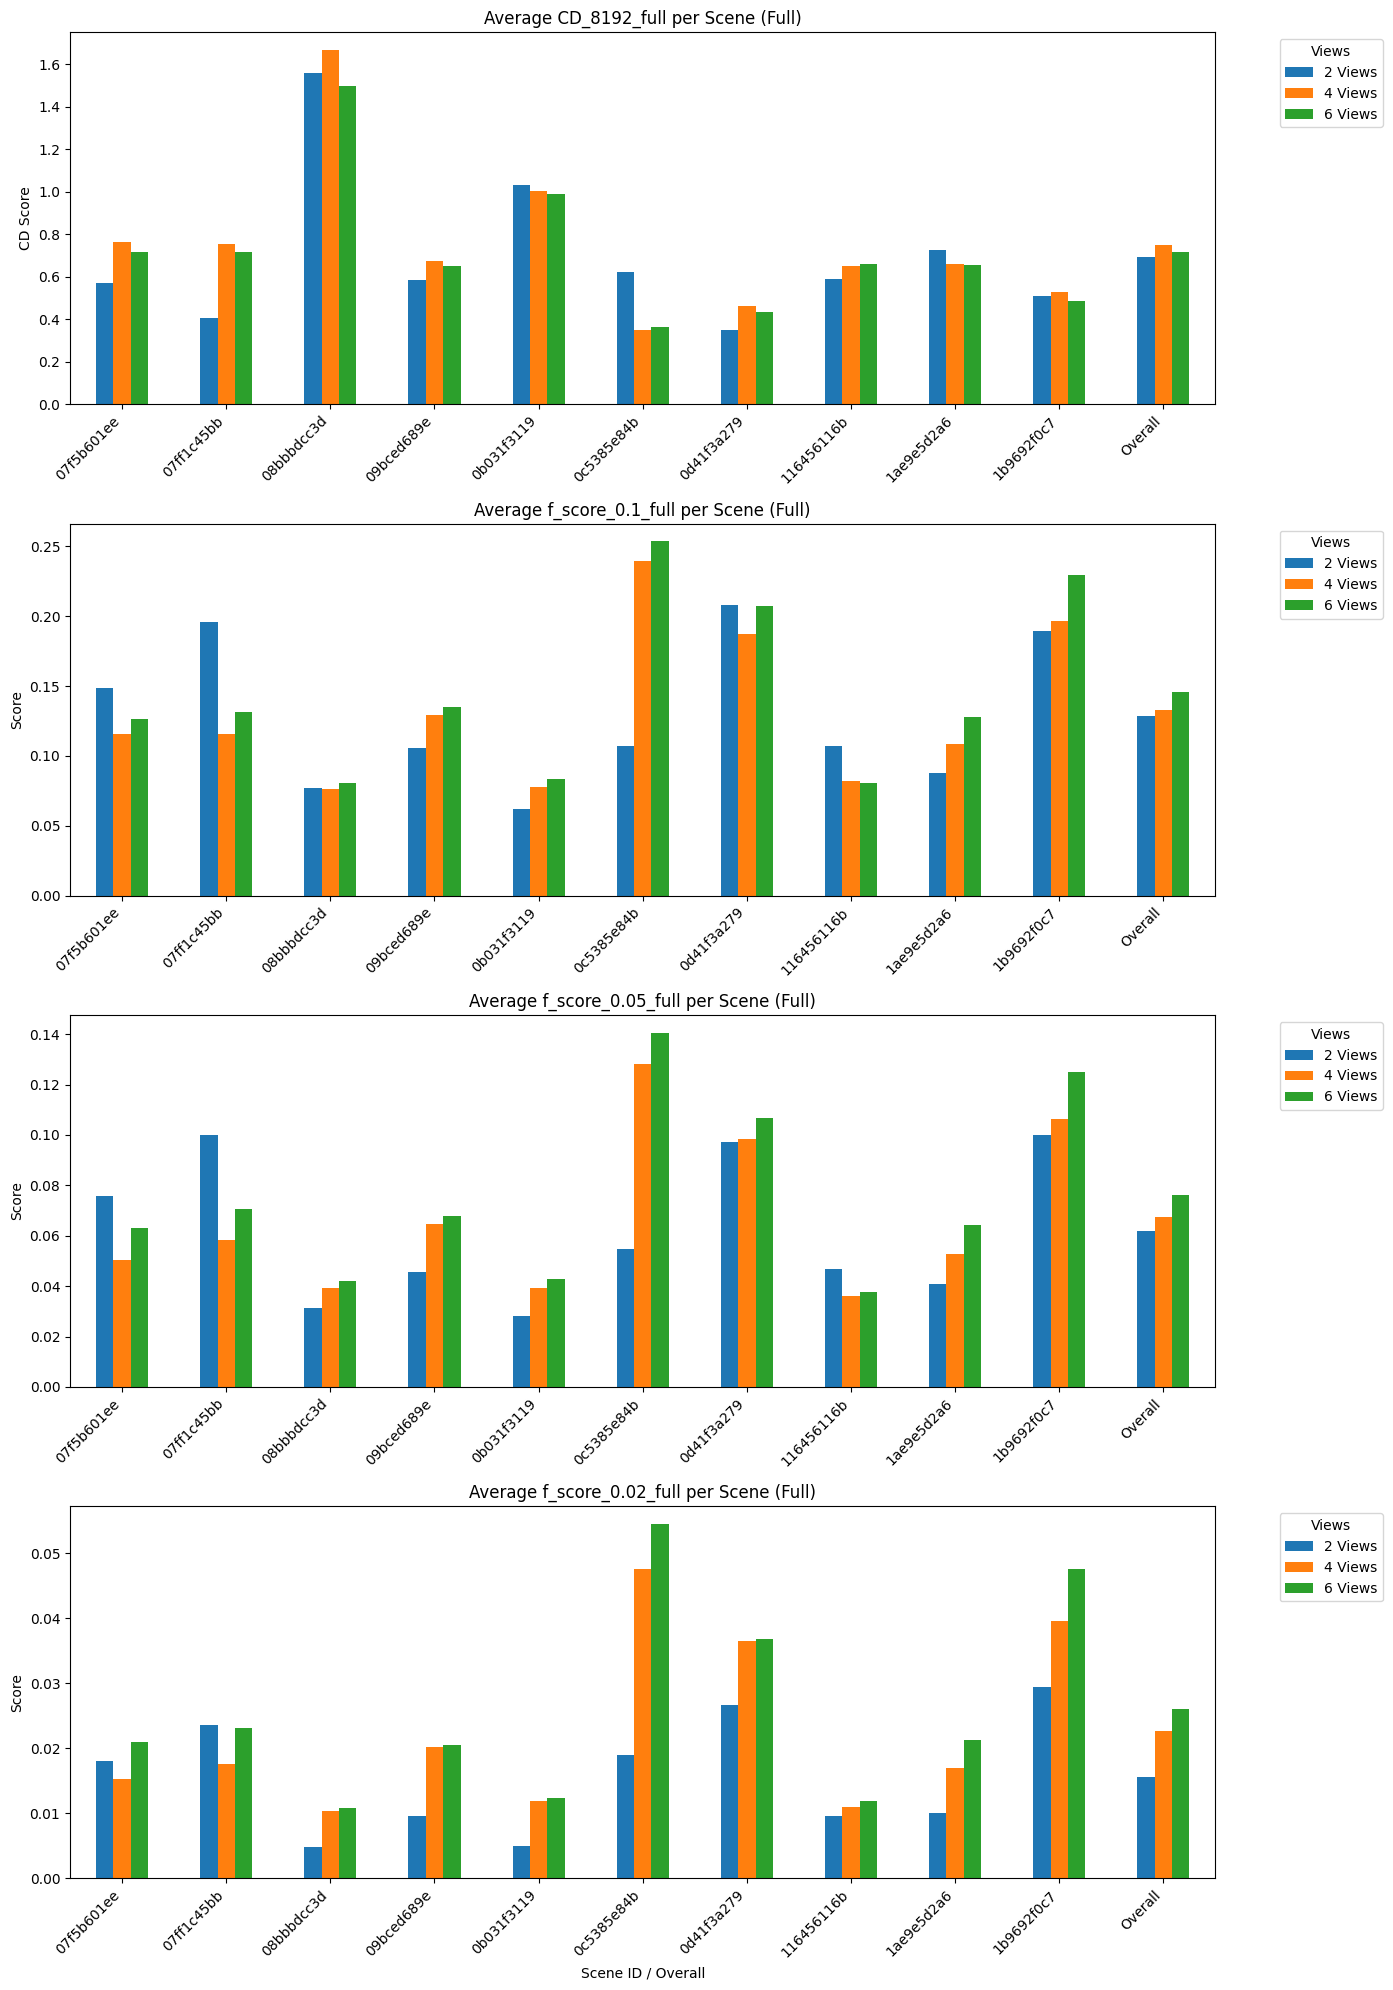


--- Overall Metrics Comparison ---


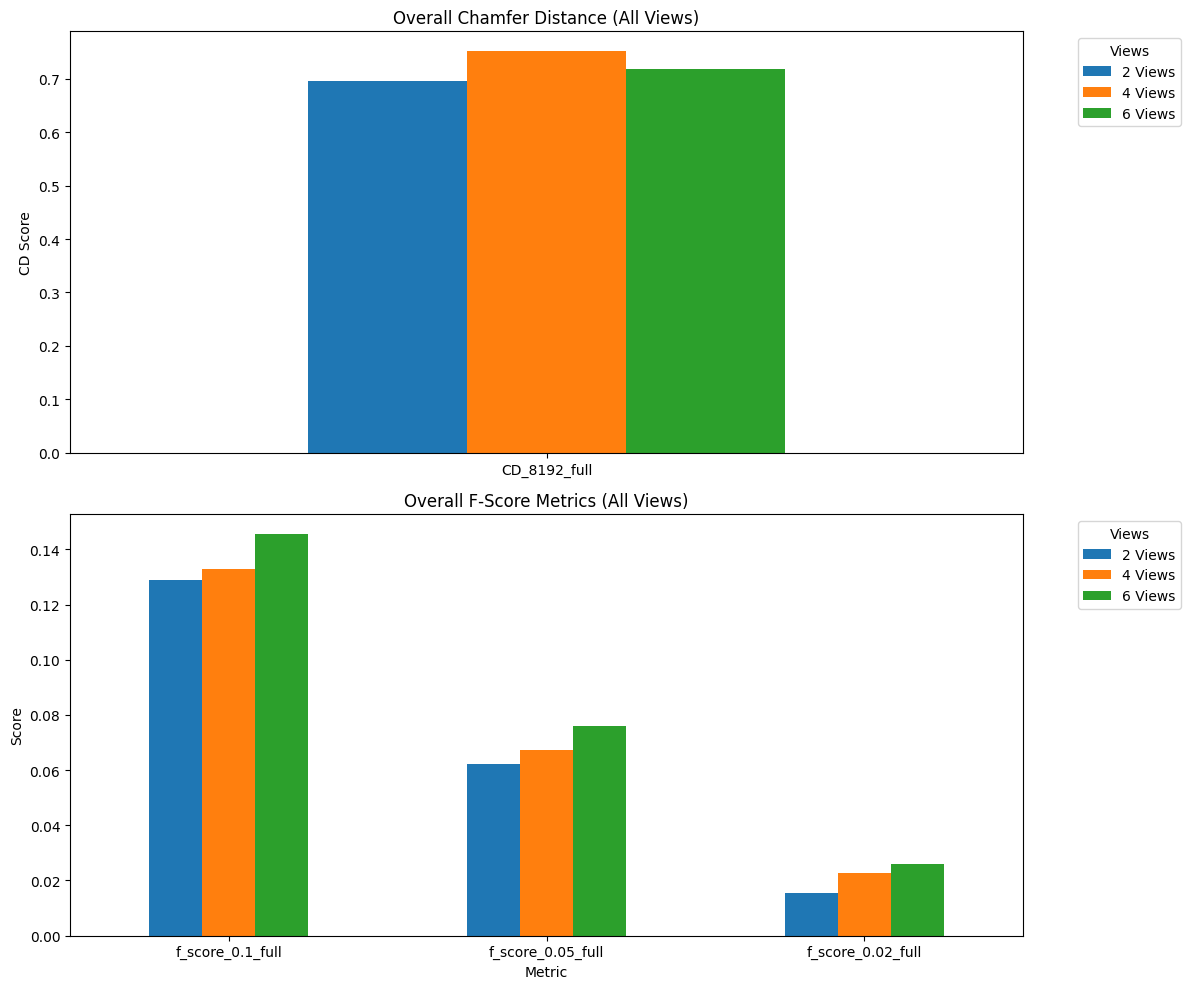

In [5]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load results from the 3 files
file_paths = {
    "2 Views": "./nova3r/evaluation_results_2.json",
    "4 Views": "./nova3r/evaluation_results_4.json",
    "6 Views": "./nova3r/evaluation_results.json", # Using evaluation_results.json as 6 views
}

all_dfs = []

for label, p in file_paths.items():
    with open(p, "r") as f:
        results = json.load(f)
        
    per_scene_avg = {}
    for scene, scene_results in results.items():
        score = {}
        for metric in scene_results[0].keys():
            if "full" not in metric:
                continue
            metric_values = [res[metric][0] for res in scene_results if metric in res]
            if metric_values:
                score[metric] = sum(metric_values) / len(metric_values)
        per_scene_avg[scene.split("/")[-1]] = score
        
    df = pd.DataFrame(per_scene_avg).T
    df.loc["Overall"] = df.mean()
    # Add a column for the number of views to distinguish them
    df["Views"] = label
    # Move Views to the first column
    cols = ["Views"] + [c for c in df.columns if c != "Views"]
    df = df[cols]
    # Set index to multi-index (Views, Scene) or keep Scene as column
    df = df.reset_index().rename(columns={"index": "Scene"})
    all_dfs.append(df)

# Combine into a single table
combined_df = pd.concat(all_dfs, ignore_index=True)

# Pivot the table to have MultiIndex columns (Metric, View)
# We want Scene as the index for plotting
pivot_df = combined_df.pivot(index="Scene", columns="Views")

print("Overall Combined Table:")
display(pivot_df)

# Separate metrics into Chamfer Distance and others (F-scores)
cd_metrics = [c for c in pivot_df.columns.levels[0] if "CD" in c and c != "Views"]
other_metrics = [c for c in pivot_df.columns.levels[0] if "CD" not in c and c != "Views"]

# Calculate number of plots needed
num_plots = len(cd_metrics) + len(other_metrics)
fig, axes = plt.subplots(num_plots, 1, figsize=(14, 5 * num_plots))

if num_plots == 1:
    axes = [axes]
    
ax_idx = 0

# Plot CD Metrics
for metric in cd_metrics:
    ax = axes[ax_idx]
    cd_df = pivot_df[metric]
    cd_df.plot(kind="bar", ax=ax, rot=45)
    ax.set_title(f"Average {metric} per Scene (Full)")
    ax.set_ylabel("CD Score")
    # Only show x label for the bottom-most plot
    ax.set_xlabel("Scene ID / Overall" if ax_idx == num_plots - 1 else "")
    plt.setp(ax.xaxis.get_majorticklabels(), ha='right')
    ax.legend(title="Views", bbox_to_anchor=(1.05, 1), loc='upper left')
    ax_idx += 1

# Plot F-Score Metrics
for metric in other_metrics:
    ax = axes[ax_idx]
    other_df = pivot_df[metric]
    other_df.plot(kind="bar", ax=ax, rot=45)
    ax.set_title(f"Average {metric} per Scene (Full)")
    ax.set_ylabel("Score")
    ax.set_xlabel("Scene ID / Overall" if ax_idx == num_plots - 1 else "")
    plt.setp(ax.xaxis.get_majorticklabels(), ha='right')
    ax.legend(title="Views", bbox_to_anchor=(1.05, 1), loc='upper left')
    ax_idx += 1

plt.tight_layout()
plt.show()

# --- Overall Only Plots ---
print("\n--- Overall Metrics Comparison ---")
# Extract just the Overall row
overall_data = pivot_df.loc["Overall"].unstack(level=1)

# Ensure correct column order
ordered_views = ["2 Views", "4 Views", "6 Views"]
ordered_views = [v for v in ordered_views if v in overall_data.columns]
overall_data = overall_data[ordered_views]

cd_overall = overall_data[overall_data.index.str.contains("CD")]
other_overall = overall_data[~overall_data.index.str.contains("CD")]

fig_over, (ax_over1, ax_over2) = plt.subplots(2, 1, figsize=(12, 10))

if not cd_overall.empty:
    cd_overall.plot(kind="bar", ax=ax_over1, rot=0)
    ax_over1.set_title("Overall Chamfer Distance (All Views)")
    ax_over1.set_ylabel("CD Score")
    ax_over1.set_xlabel("")
    ax_over1.legend(title="Views", bbox_to_anchor=(1.05, 1), loc='upper left')

if not other_overall.empty:
    other_overall.plot(kind="bar", ax=ax_over2, rot=0)
    ax_over2.set_title("Overall F-Score Metrics (All Views)")
    ax_over2.set_ylabel("Score")
    ax_over2.set_xlabel("Metric")
    ax_over2.legend(title="Views", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

python demo_nova3r.py --images /mnt/d/scannet/data/07ff1c45bb/panocam/images/0_cube_120/0000.jpg /mnt/d/scannet/data/07ff1c45bb/panocam/images/0_cube_120/0001.jpg /mnt/d/scannet/data/07ff1c45bb/panocam/images/0_cube_120/0002.jpg /mnt/d/scannet/data/07ff1c45bb/panocam/images/0_cube_120/0003.jpg /mnt/d/scannet/data/07ff1c45bb/panocam/images/0_cube_120/0004.jpg /mnt/d/scannet/data/07ff1c45bb/panocam/images/0_cube_120/0005.jpg
 --ckpt checkpoints/scene_n2/checkpoint-last.pth --num_queries 1000000

python test_image_gen.py --image /mnt/d/scannet/data/07ff1c45bb/panocam/images/0.jpg  --fov 90 --num_views 2 --degree_offset 20

In [6]:
import torch
from pytorch3d import _C

N, P, D = 4, 1000, 3
K = 128

points = torch.randn(N, P, D).cuda()
lengths = torch.full((N,), P, dtype=torch.long).cuda()
start_idxs = torch.zeros(N, dtype=torch.long).cuda()
# arg3: initial distance buffer
init_dist = torch.full((N, P), 1e10, dtype=torch.long, device="cuda")

# Calling the _C extension with the 5 arguments
indices = _C.sample_farthest_points(points, lengths, start_idxs, init_dist, K)

print(indices.shape) # torch.Size([4, 128])

RuntimeError: TensorAccessor expected 1 dims but tensor has 2

In [ ]:
import numpy as np
import torch
import os

noise_path = "fixed_noise_16k.npy"

if not os.path.exists(noise_path):
    # Generate once and save
    # Shape: (1, 8000, 3)
    initial_noise = np.random.randn(1, 16384, 3).astype(np.float32)
    np.save(noise_path, initial_noise)
    print(f"Saved new noise to {noise_path}")

# Load and convert to Torch
noise_np = np.load(noise_path)
fixed_noise = torch.from_numpy(noise_np).cuda()

: 